# Kingdom of England in 1185

Map of the Kingdom of England in 1185 using Cliopatria polity boundary data from `cliopatria_polities_only.geojson`.

The Cliopatria dataset records this as the **(Kingdom of England)** polity period **1177-1187**, which corresponds to the reign of Henry II and the Angevin Empire — England plus vast continental holdings from Normandy to Aquitaine.

In [1]:
import json
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from shapely.geometry import shape, MultiPolygon, Polygon

## 1. Load GeoJSON and find Kingdom of England in 1185

In [2]:
with open('../cliopatria_data/cliopatria_polities_only.geojson', 'r') as f:
    data = json.load(f)

print(f'Total features in GeoJSON: {len(data["features"]):,}')

# Find the Kingdom of England feature covering year 1185
target = None
for feat in data['features']:
    name = feat['properties']['Name']
    from_y = feat['properties']['FromYear']
    to_y = feat['properties']['ToYear']
    if 'kingdom of england' in name.lower() and from_y <= 1185 <= to_y:
        target = feat
        break

props = target['properties']
geom = shape(target['geometry'])

print(f'Polity: {props["Name"]}')
print(f'Period: {props["FromYear"]}-{props["ToYear"]}')
print(f'Geometry: {geom.geom_type}')
print(f'Bounding box: {geom.bounds}')
print(f'Area: {props["Area"]:,.0f}')

Total features in GeoJSON: 15,690
Polity: (Kingdom of England)
Period: 1177-1187
Geometry: MultiPolygon
Bounding box: (-7.905546188354492, 42.691246032714844, 4.359247207641602, 55.90821838378906)
Area: 371,721


## 2. Find neighboring polities for context

In [3]:
minx, miny, maxx, maxy = geom.bounds

neighbors = []
for feat in data['features']:
    from_y = feat['properties']['FromYear']
    to_y = feat['properties']['ToYear']
    if from_y <= 1185 <= to_y and feat != target:
        g = shape(feat['geometry'])
        gb = g.bounds
        # Keep polities in the general area (Western Europe)
        if gb[0] >= minx - 15 and gb[2] <= maxx + 15 and gb[1] >= miny - 10 and gb[3] <= maxy + 10:
            neighbors.append((feat, g))

print(f'Neighboring polities found: {len(neighbors)}')
for feat, g in sorted(neighbors, key=lambda x: -x[0]['properties']['Area'])[:15]:
    p = feat['properties']
    print(f"  {p['Name']:40s} Area: {p['Area']:>10,.0f}  ({p['FromYear']}-{p['ToYear']})")

Neighboring polities found: 47
  Holy Roman Empire                        Area:    889,503  (1177-1187)
  (Holy Roman Empire)                      Area:    889,503  (1177-1187)
  Angevin Empire                           Area:    371,721  (1177-1187)
  (Kingdom of France)                      Area:    212,714  (1177-1187)
  (Kingdom of Sweden)                      Area:    145,563  (1056-1205)
  Kingdom of Sweden                        Area:    145,563  (1056-1205)
  (Kingdom of Denmark)                     Area:    111,266  (1177-1187)
  Kingdom of Denmark                       Area:    111,266  (1177-1187)
  Kingdom of León                          Area:    110,323  (1169-1187)
  Kingdom of Castile                       Area:    106,184  (1169-1187)
  Kingdom of Sicily                        Area:     92,074  (1177-1201)
  Kingdom of Portugal                      Area:     68,008  (1177-1187)
  Crown of Aragon                          Area:     66,315  (1177-1187)
  Kingdom of Alba   

## 3. Plot the map

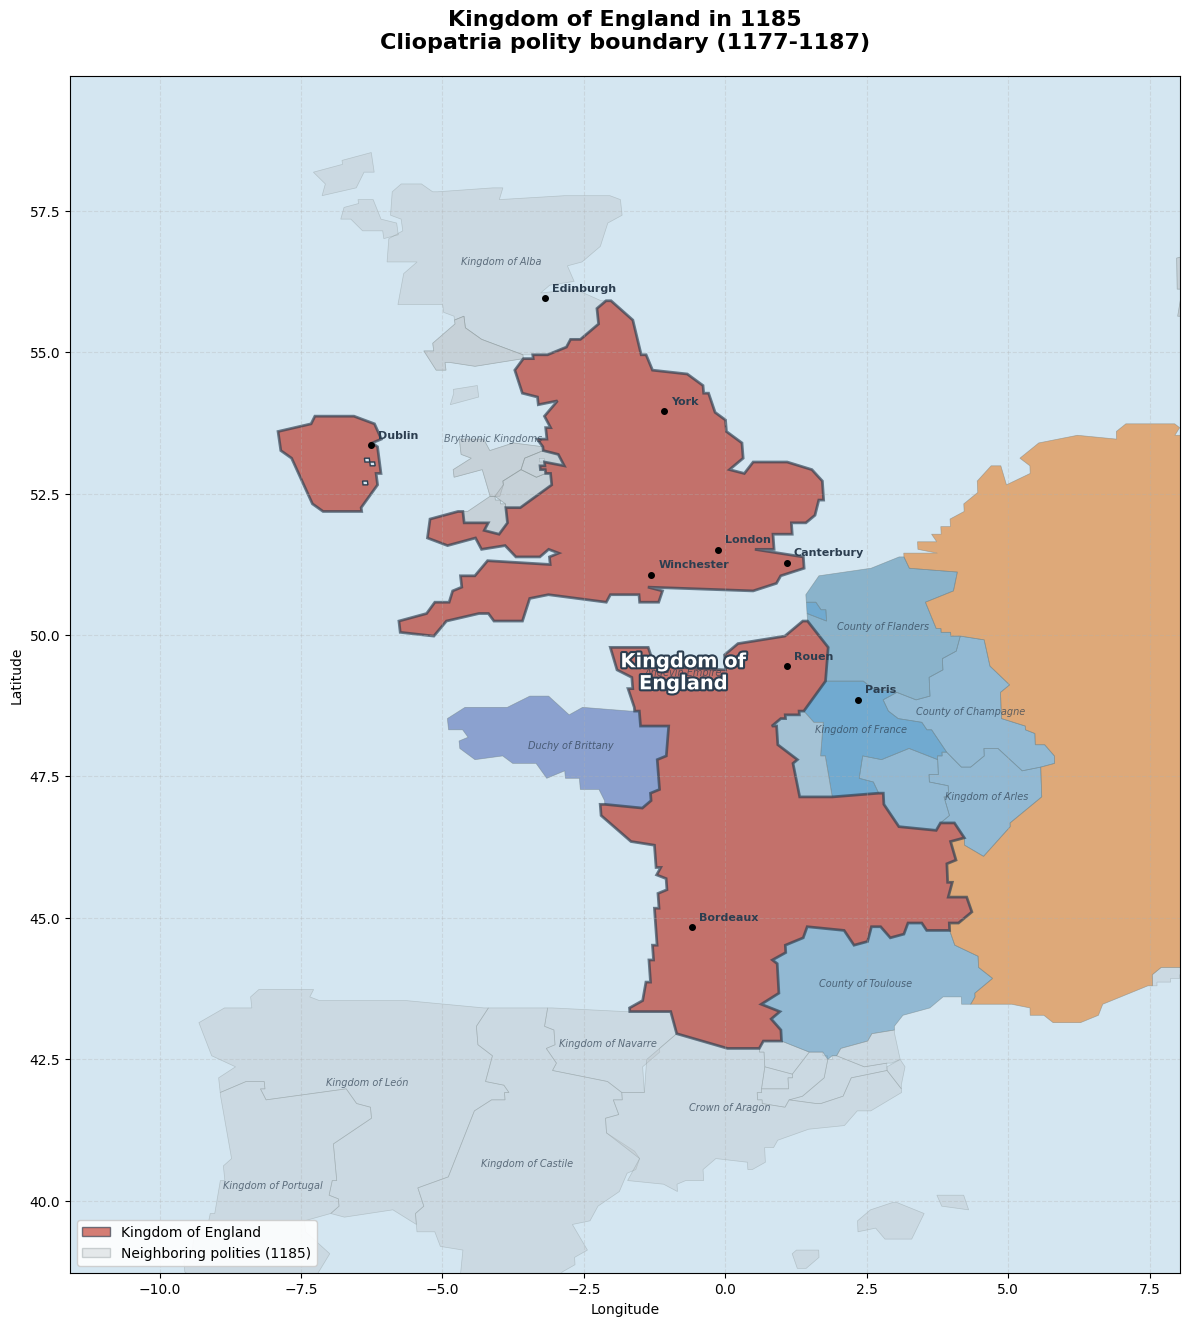

In [4]:
# Color map for known neighbors
color_map = {
    'kingdom of france': '#2980b9',
    'kingdom of scotland': '#27ae60',
    'wales': '#f39c12',
    'ireland': '#8e44ad',
    'principality of wales': '#f39c12',
    'kingdom of norway': '#1abc9c',
    'holy roman empire': '#e67e22',
    'county of flanders': '#95a5a6',
    'duchy of normandy': '#3498db',
    'duchy of brittany': '#9b59b6',
    'duchy of aquitaine': '#2471a3',
    'norman england': '#e74c3c',
}

# Reference places
places = {
    'London': (-0.1278, 51.5074),
    'York': (-1.0808, 53.9583),
    'Canterbury': (1.0833, 51.2802),
    'Winchester': (-1.3081, 51.0632),
    'Dublin': (-6.2603, 53.3498),
    'Edinburgh': (-3.1883, 55.9533),
    'Paris': (2.3522, 48.8566),
    'Rouen': (1.0993, 49.4432),
    'Bordeaux': (-0.5792, 44.8378),
}


def plot_geom(g, ax, fc, ec, alpha, lw):
    """Plot a Shapely geometry (Polygon or MultiPolygon) on a matplotlib axis."""
    if isinstance(g, MultiPolygon):
        for poly in g.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=alpha, fc=fc, ec=ec, linewidth=lw)
            for interior in poly.interiors:
                ix, iy = interior.xy
                ax.fill(ix, iy, alpha=1.0, fc='#d4e6f1', ec=ec, linewidth=lw * 0.5)
    elif isinstance(g, Polygon):
        x, y = g.exterior.xy
        ax.fill(x, y, alpha=alpha, fc=fc, ec=ec, linewidth=lw)


# --- Build the figure ---
pad_x = (maxx - minx) * 0.3
pad_y = (maxy - miny) * 0.3

fig, ax = plt.subplots(1, 1, figsize=(12, 14))
ax.set_facecolor('#d4e6f1')  # sea color

# Plot neighbors first (background)
plotted_names = set()
for feat, g in neighbors:
    name = feat['properties']['Name'].strip('()')
    name_lower = name.lower()

    color = '#bdc3c7'  # default grey
    for key, c in color_map.items():
        if key in name_lower:
            color = c
            break

    plot_geom(g, ax, color, '#7f8c8d', 0.35, 0.5)

    # Label large polities once
    if name not in plotted_names and feat['properties']['Area'] > 15000:
        cx, cy = g.centroid.x, g.centroid.y
        if minx - 10 <= cx <= maxx + 10 and miny - 5 <= cy <= maxy + 5:
            ax.annotate(name, xy=(cx, cy),
                        fontsize=7, ha='center', va='center', color='#2c3e50',
                        alpha=0.7, style='italic')
            plotted_names.add(name)

# Plot Kingdom of England on top
plot_geom(geom, ax, '#c0392b', '#2c3e50', 0.65, 2)

# Label
centroid = geom.centroid
ax.annotate('Kingdom of\nEngland', xy=(centroid.x, centroid.y),
            fontsize=14, ha='center', va='center', color='white',
            fontweight='bold',
            path_effects=[pe.withStroke(linewidth=3, foreground='#2c3e50')])

# Reference places
for city, (lon, lat) in places.items():
    if minx - 10 <= lon <= maxx + 10 and miny - 5 <= lat <= maxy + 5:
        ax.plot(lon, lat, 'ko', markersize=4, zorder=5)
        ax.annotate(city, xy=(lon, lat), xytext=(5, 5),
                    textcoords='offset points', fontsize=8, color='#2c3e50',
                    fontweight='bold', zorder=5)

# Formatting
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect('equal')
ax.set_title(f'Kingdom of England in 1185\nCliopatria polity boundary ({props["FromYear"]}-{props["ToYear"]})',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#c0392b', edgecolor='#2c3e50', alpha=0.65, label='Kingdom of England'),
    mpatches.Patch(facecolor='#bdc3c7', edgecolor='#7f8c8d', alpha=0.35, label='Neighboring polities (1185)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()